In [1]:
import gc

import matplotlib.pyplot as plt
import mrcfile
import torch

from cryosim.array_utils import radial_profile_2d, radial_symmetrize
from cryosim.fft_tools import fft2
from cryosim.filters import butter
from cryosim.icemaker import Icemaker
from cryosim.imagegenerator import TiltSeriesGenerator
from cryosim.plotting_tools import plot3d

%load_ext autoreload
%autoreload 2

## Helper function to clear GPU memory

In [2]:
def clear_memory(*names):
    torch.cuda.synchronize()

    before_alloc = torch.cuda.memory_allocated()
    before_reserved = torch.cuda.memory_reserved()

    # delete requested globals
    for name in names:
        if name in globals():
            del globals()[name]

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    after_alloc = torch.cuda.memory_allocated()
    after_reserved = torch.cuda.memory_reserved()

    freed_alloc = (before_alloc - after_alloc) / 1024**2
    freed_reserved = (before_reserved - after_reserved) / 1024**2

    print(f"Freed {freed_alloc:.2f} MB (allocated)")
    print(f"Freed {freed_reserved:.2f} MB (reserved cache)")
    print(f"Now allocated: {after_alloc / 1024**2:.2f} MB")

## Import potential volume created elsewhere (TomogramGenerator or Polnet)

In [3]:
with mrcfile.open(
    "/mnt/cbis/home/e0788253/polnet/gui/tomo_density_2100x2100x600_3A.mrc"
) as mrc:
    tomo = torch.as_tensor(mrc.data[...].copy())
print(tomo.shape)

torch.Size([600, 2100, 2100])


In [4]:
dx = 3  # voxel size based on imported volume

## Add ice

In [5]:
max_tilt_angle = torch.tensor(45.0)
required_nxy = TiltSeriesGenerator._estimate_required_nxy(
    tomo.shape[-1], tomo.shape[0], max_tilt_angle
)
print(required_nxy)

3570


In [6]:
# note: change ice_dx to range between 1.25 - 0.5 A. This is needed for our
# ice algorithm to work normally.
# choose value based on integer division with dx.
# for e.g., for dx = 10A, we can choose ice_dx = 1A with bin_factor of 10.
bin_factor = 4
ice_dx = dx / bin_factor  # this should range between 0.5A - 1.25A
im = Icemaker(n=256, dx=ice_dx)  # keep n=256.
print(ice_dx)

0.75


In [7]:
ice = torch.squeeze(
    im.generate_big_ice_fast(
        (
            1,
            tomo.shape[0] * bin_factor,
            tomo.shape[1] * bin_factor,
            tomo.shape[2] * bin_factor,
        ),
        bin_factor=bin_factor,
    )
)
ice.shape

Output()

bin_factor = 4, outputing target shape of (1, 600, 2100, 2100)
Recomputing ice kernal at 3.0 A pixel size.


torch.Size([600, 2100, 2100])

In [8]:
tomo_to_ice_ratio = 0.75
# ice, tomo = pad_to_common_shape(ice, tomo)
tomogram = tomo * torch.max(ice) * tomo_to_ice_ratio + ice * (tomo < 0.1)

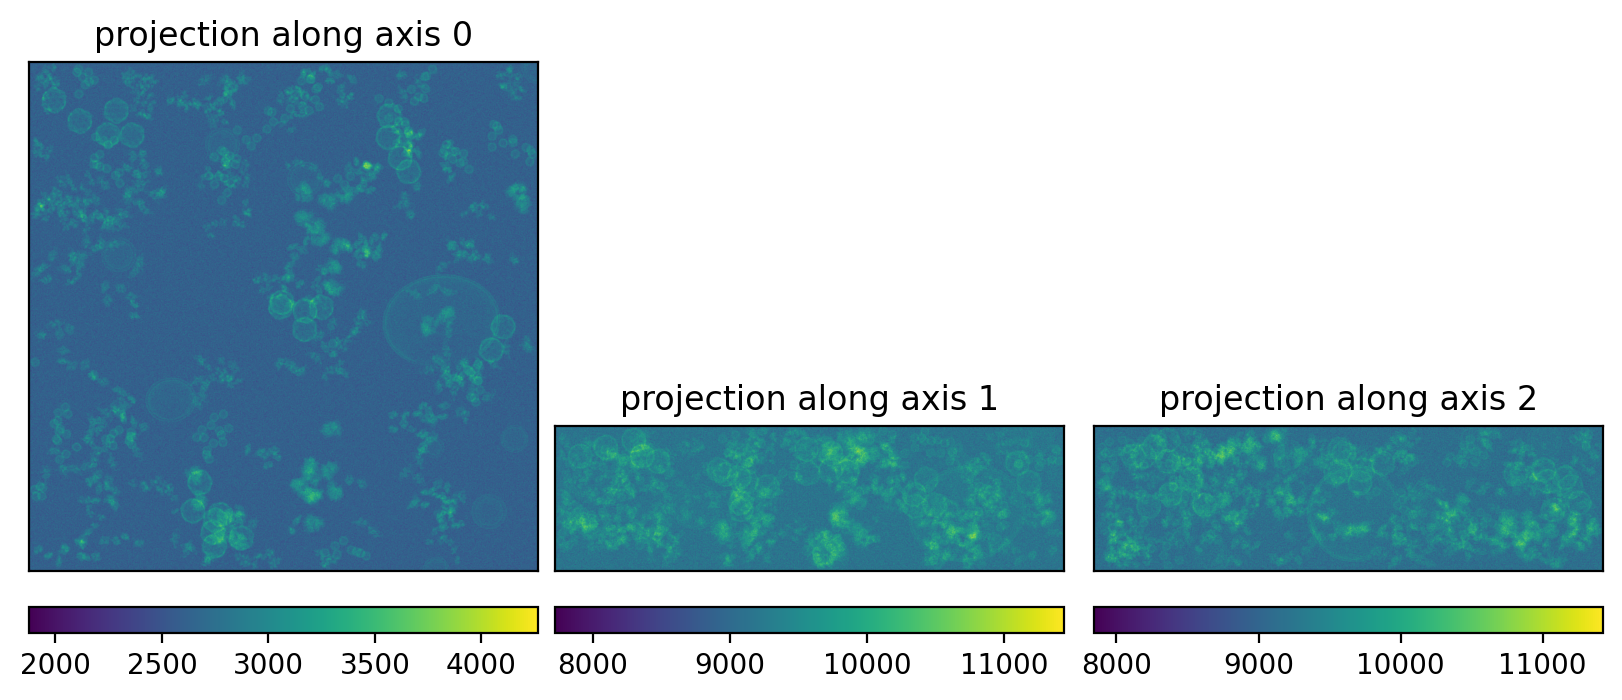

In [9]:
plot3d(tomogram)

## Micrograph class

In [10]:
n_micrographs = 1
energy = 300  # keV
dose_per_angstrom = 3.226  # e-/A^2
Cs = 2e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1
micrograph_size = tomo.shape[-1]
num_frames = 10  # usually ~ 1-2 e-/A^2/frame

In [11]:
device = "cuda:0"  # choose cpu if you run out of cuda memory.

In [12]:
# random defocus
defocus_A = torch.tensor(22000.0)


# Can include 'cs', 'dfu', 'dfv', 'dfang', 'tiltx', 'tilty', 'phaseshift', 'trefoil1, 'trefoil2'
ctf_params = {
    "cs": torch.tensor([Cs] * n_micrographs).to(device),
    "dfu": defocus_A.to(device),
}

In [13]:
angles = torch.linspace(-45, 45, 3)
angles

tensor([-45.,   0.,  45.])

In [43]:
coincidence_radius = 1.5  # angstrom. Higher value reduces lower spatial frequencies. Set to 0 for default Poisson

model = TiltSeriesGenerator(
    tomogram[None, ...],
    micrograph_size,
    dx,
    ctf_params,
    energy,
    dose_per_angstrom,
    angles=angles,
    scattering_model="multislice",
    noise_model="poisson",
    alpha=alpha,
    tilt_axis="y",
    coincidence_radius=coincidence_radius,
    num_frames=num_frames,
    # taper_width=100,
    # z_taper_width=100,
).to(device)

[TiltSeriesGenerator] Volume XY too small for requested tilt coverage; padded (reflect) from 2100 to 3570 px in XY.
  micrograph_size=2100, requested_max_tilt=45.00 deg, required_volume_nxy>=3570.
[TiltSeriesGenerator] Volume on GPU.


In [42]:
# use this if you want to rerun the model code block to clear GPU vram.
clear_memory("model")

Freed 29305.35 MB (allocated)
Freed 31016.00 MB (reserved cache)
Now allocated: 8.13 MB


In [44]:
with torch.no_grad():
    images, exitwaves, cleans = model.generate_tilt_series(torch.tensor([0]))
images.shape

Output()

torch.Size([1, 3, 2100, 2100])

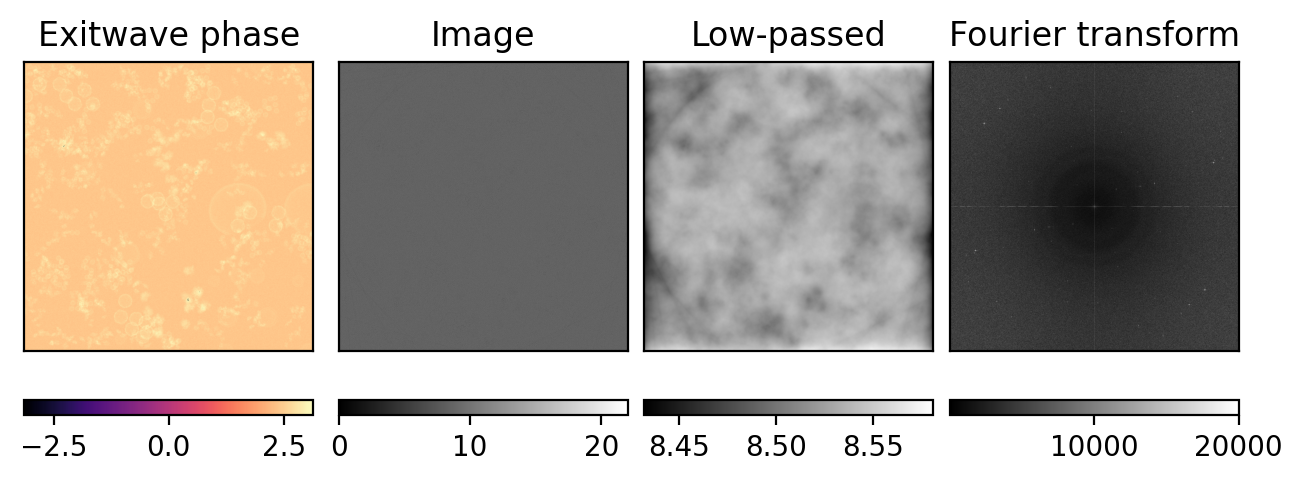

In [45]:
idx = 0

fig, axes = plt.subplots(1, 4, constrained_layout=True, dpi=200)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
ax = axes[0]
im = ax.imshow(torch.angle(exitwaves[0, idx]), cmap="magma")
fig.colorbar(im, ax=ax, location="bottom")
ax.set_title("Exitwave phase")

ax = axes[1]
im = ax.imshow(images[0, idx], cmap="grey")
fig.colorbar(im, ax=ax, location="bottom")
ax.set_title("Image")

ax = axes[2]
im = ax.imshow(butter(images[0, idx]), cmap="grey")
fig.colorbar(im, ax=ax, location="bottom")
ax.set_title("Low-passed")

ax = axes[3]
im = ax.imshow(
    torch.abs(fft2(images[0, idx] - images[0, idx].mean(), shift=True)),
    cmap="grey",
    vmax=20000,
)
ax.set_title("Fourier transform")
fig.colorbar(im, ax=ax, location="bottom")
plt.show()

Text(0.5, 1.0, 'FFT2')

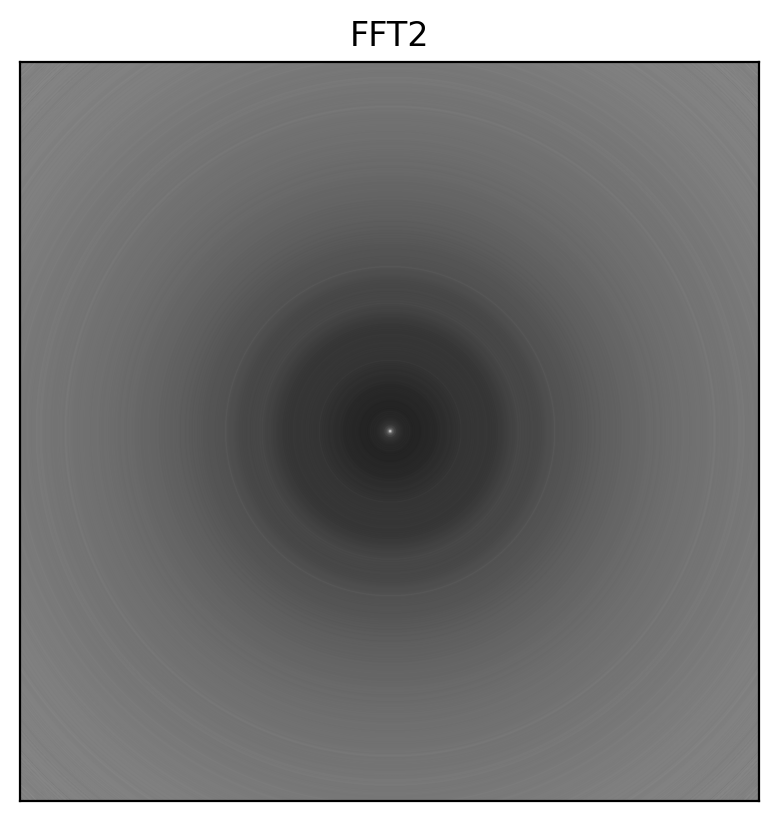

In [46]:
plt.figure(dpi=200)
plt.imshow(
    radial_symmetrize(torch.abs(fft2(images[0, 0] - images[0, 0].mean(), shift=True))),
    cmap="grey",
)
plt.xticks([])
plt.yticks([])
plt.title("FFT2")

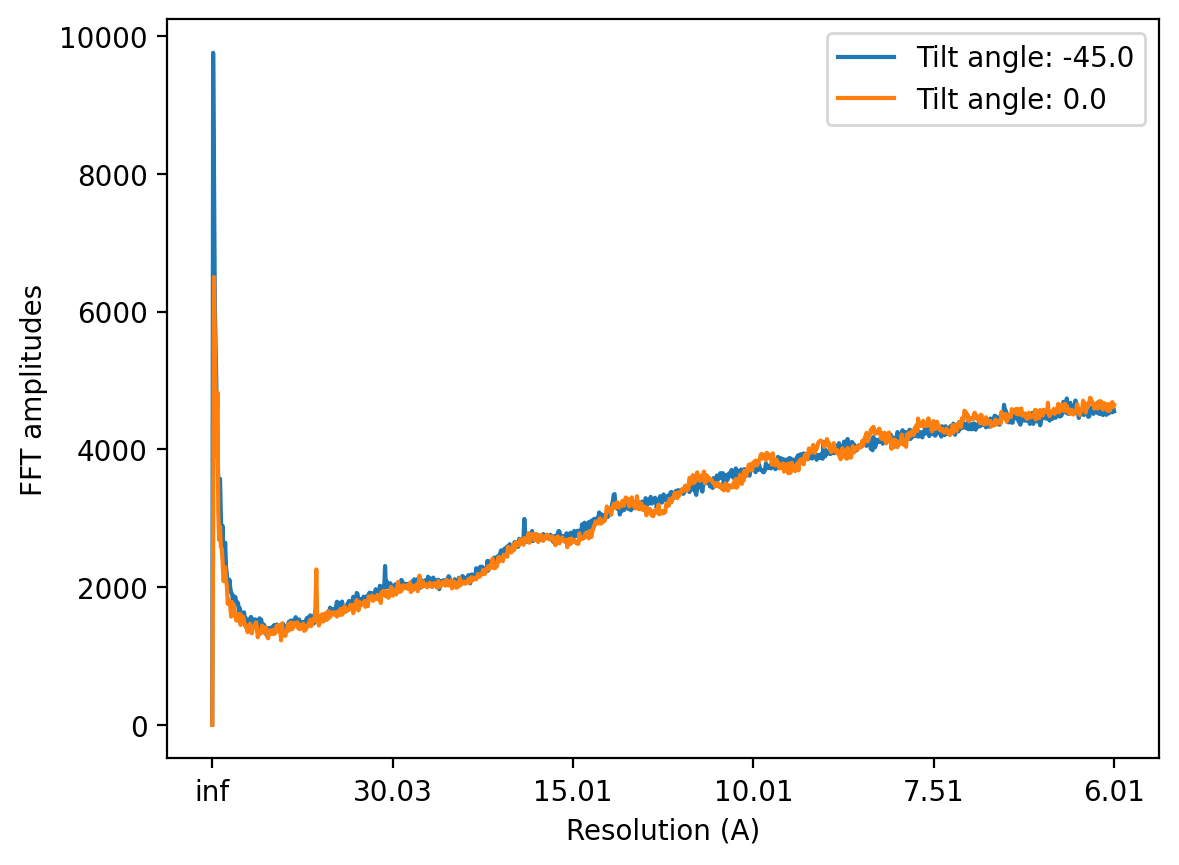

In [47]:
freqs = torch.fft.fftfreq(micrograph_size, dx)[: micrograph_size // 2]
plt.figure(dpi=200)
for i in range(2):
    radial_prof = radial_profile_2d(
        torch.abs(fft2(images[0, i] - images[0, i].mean(), shift=True))
    )
    plt.plot(
        freqs, radial_prof[: micrograph_size // 2], label=f"Tilt angle: {angles[i]}"
    )
    # plt.ylim([5000, 20000])
    plt.ylabel("FFT amplitudes")
    plt.xlabel("")
    xticks = torch.linspace(freqs[0], freqs[-1], 6)
    xticklabels = [f"{1 / k:.2f}" for k in xticks]
    xticklabels[0] = torch.inf
    plt.xticks(xticks, xticklabels)
    plt.xlabel("Resolution (A)")
    plt.legend()

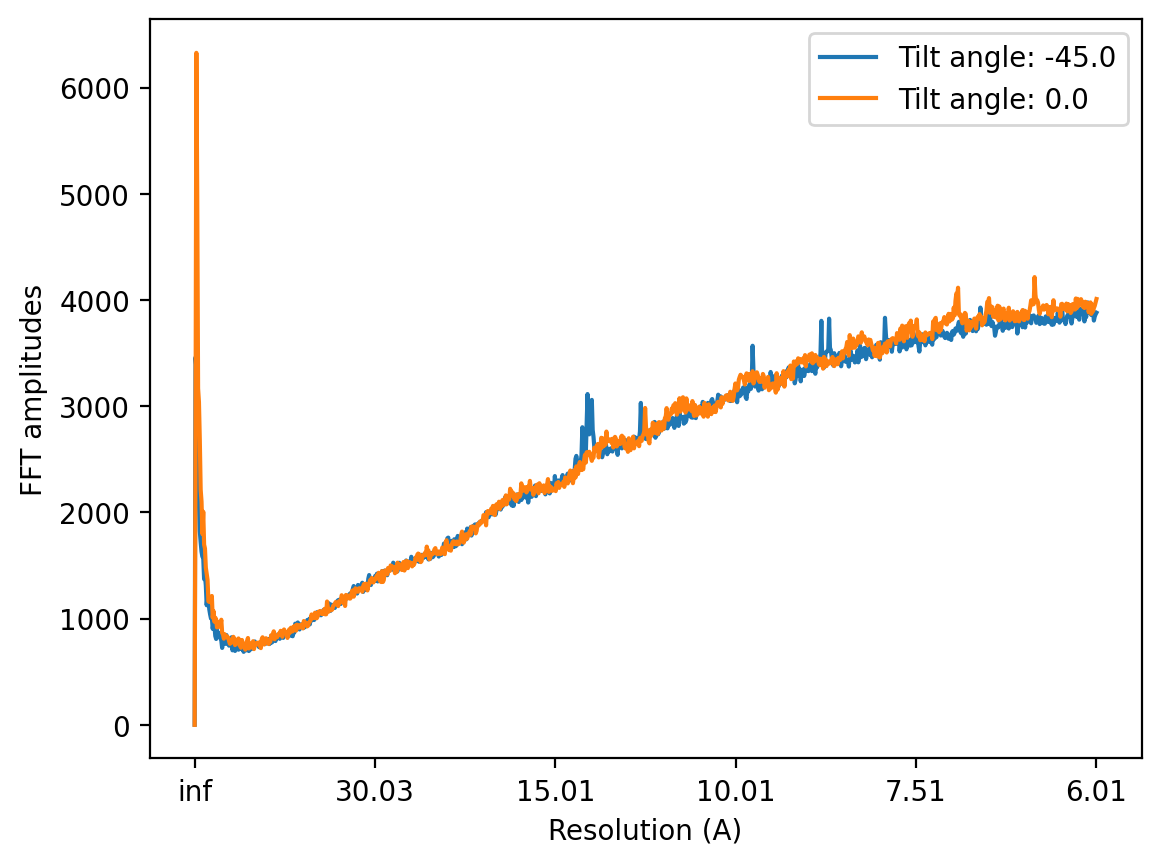

In [35]:
freqs = torch.fft.fftfreq(micrograph_size, dx)[: micrograph_size // 2]
plt.figure(dpi=200)
for i in range(2):
    radial_prof = radial_profile_2d(
        torch.abs(fft2(images[0, i] - images[0, i].mean(), shift=True))
    )
    plt.plot(
        freqs, radial_prof[: micrograph_size // 2], label=f"Tilt angle: {angles[i]}"
    )
    # plt.ylim([5000, 20000])
    plt.ylabel("FFT amplitudes")
    plt.xlabel("")
    xticks = torch.linspace(freqs[0], freqs[-1], 6)
    xticklabels = [f"{1 / k:.2f}" for k in xticks]
    xticklabels[0] = torch.inf
    plt.xticks(xticks, xticklabels)
    plt.xlabel("Resolution (A)")
    plt.legend()

In [ ]:
# import imageio.v2 as imageio

# # your tensor: shape (5, 1024, 1024)
# imgs = tilt_series[0].cpu().numpy()

# frames = []

# for i in range(imgs.shape[0]):
#     fig, ax = plt.subplots(figsize=(5, 5), dpi=200)
#     ax.imshow(imgs[i], cmap="gray", vmax=30, vmin=10)
#     ax.axis("off")
#     ax.set(title=f"{angles[i]}$^\circ$")

#     fig.canvas.draw()

#     # Get RGBA buffer → convert to RGB
#     buf = np.asarray(fig.canvas.renderer.buffer_rgba())
#     frame = buf[:, :, :3]  # drop alpha channel

#     frames.append(frame)
#     plt.close(fig)

# # Save GIF at 2 FPS
# imageio.mimsave("output_2048_noisy.gif", frames, fps=2, loop=0)